# Global Youtube Statistics EDA Project

In [1]:
# Import all modules needed
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Setting the global result format 
pd.options.display.float_format = '{:,.2f}'.format

In [3]:
# Get the data
df = pd.read_csv("Global YouTube Statistics.csv", encoding = "latin1")

In [4]:
# Print the first 10 rows of data
df.head(10)

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,"228,000,000,000.00",Music,T-Series,20082,India,IN,Music,...,"2,000,000.00","2,006.00",Mar,13.00,28.10,"1,366,417,754.00",5.36,"471,031,528.00",20.59,78.96
1,2,YouTube Movies,170000000,0.00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,"2,006.00",Mar,5.00,88.20,"328,239,523.00",14.70,"270,663,028.00",37.09,-95.71
2,3,MrBeast,166000000,"28,368,841,870.00",Entertainment,MrBeast,741,United States,US,Entertainment,...,"8,000,000.00","2,012.00",Feb,20.00,88.20,"328,239,523.00",14.70,"270,663,028.00",37.09,-95.71
3,4,Cocomelon - Nursery Rhymes,162000000,"164,000,000,000.00",Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,"1,000,000.00","2,006.00",Sep,1.00,88.20,"328,239,523.00",14.70,"270,663,028.00",37.09,-95.71
4,5,SET India,159000000,"148,000,000,000.00",Shows,SET India,116536,India,IN,Entertainment,...,"1,000,000.00","2,006.00",Sep,20.00,28.10,"1,366,417,754.00",5.36,"471,031,528.00",20.59,78.96
5,6,Music,119000000,0.00,NaN,Music,0,NaN,NaN,Music,...,NaN,"2,013.00",Sep,24.00,NaN,NaN,NaN,NaN,NaN,NaN
6,7,ýýý Kids Diana Show,112000000,"93,247,040,539.00",People & Blogs,ýýý Kids Diana Show,1111,United States,US,Entertainment,...,NaN,"2,015.00",May,12.00,88.20,"328,239,523.00",14.70,"270,663,028.00",37.09,-95.71
7,8,PewDiePie,111000000,"29,058,044,447.00",Gaming,PewDiePie,4716,Japan,JP,Entertainment,...,NaN,"2,010.00",Apr,29.00,63.20,"126,226,568.00",2.29,"115,782,416.00",36.20,138.25
8,9,Like Nastya,106000000,"90,479,060,027.00",People & Blogs,Like Nastya Vlog,493,Russia,RU,People,...,"100,000.00","2,016.00",Jan,14.00,81.90,"144,373,535.00",4.59,"107,683,889.00",61.52,105.32
9,10,Vlad and Niki,98900000,"77,180,169,894.00",Entertainment,Vlad and Niki,574,United States,US,Entertainment,...,"600,000.00","2,018.00",Apr,23.00,88.20,"328,239,523.00",14.70,"270,663,028.00",37.09,-95.71


In [5]:
# Get the column names
df.columns

Index(['rank', 'Youtuber', 'subscribers', 'video views', 'category', 'Title',
       'uploads', 'Country', 'Abbreviation', 'channel_type',
       'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'Gross tertiary education enrollment (%)', 'Population',
       'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude'],
      dtype='object')

In [6]:
# Get the general information on all the dataframe features(columns)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    object 
 5   Title                                    995 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    object 
 8   Abbreviation                             873 non-null    object 
 9   channel_type                             965 non-null    object 
 10  video_views_rank                         994 non-n

In [7]:
# Get the statistical characteristics for each numerical feature(column)
df.describe()

,rank,subscribers,video views,uploads,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,...,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
count,995.00,995.00,995.00,995.00,994.00,879.00,962.00,939.00,995.00,995.00,...,995.00,658.00,990.00,990.00,872.00,872.00,872.00,872.00,872.00,872.00
mean,498.00,"22,982,412.06","11,039,537,052.04","9,187.13","554,248.90",386.05,745.72,"175,610,284.79","36,886.15","589,807.85",...,"7,081,813.92","349,079.13","2,012.63",15.75,63.63,"430,387,266.75",9.28,"224,214,981.63",26.63,-14.13
std,287.38,"17,526,105.34","14,110,844,376.83","34,151.35","1,362,782.21","1,232.24","1,944.39","416,378,166.21","71,858.72","1,148,622.48",...,"13,797,037.61","614,355.44",4.51,8.78,26.11,"472,794,722.46",4.89,"154,687,362.71",20.56,84.76
min,1.00,"12,300,000.00",0.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,...,0.00,1.00,"1,970.00",1.00,7.60,"202,506.00",0.75,"35,588.00",-38.42,-172.10
25%,249.50,"14,500,000.00","4,288,145,410.00",194.50,323.00,11.00,27.00,"20,137,500.00","2,700.00","43,500.00",...,"521,750.00","100,000.00","2,009.00",8.00,36.30,"83,355,411.00",5.27,"55,908,316.00",20.59,-95.71
50%,498.00,"17,700,000.00","7,760,819,588.00",729.00,915.50,51.00,65.50,"64,085,000.00","13,300.00","212,700.00",...,"2,600,000.00","200,000.00","2,013.00",16.00,68.00,"328,239,523.00",9.37,"270,663,028.00",37.09,-51.93
75%,746.50,"24,600,000.00","13,554,701,853.00","2,667.50","3,584.50",123.00,139.75,"168,826,500.00","37,900.00","606,800.00",...,"7,300,000.00","400,000.00","2,016.00",23.00,88.20,"328,239,523.00",14.70,"270,663,028.00",37.09,78.96
max,995.00,"245,000,000.00","228,000,000,000.00","301,308.00","4,057,944.00","7,741.00","7,741.00","6,589,000,000.00","850,900.00","13,600,000.00",...,"163,400,000.00","8,000,000.00","2,022.00",31.00,113.10,"1,397,715,000.00",14.72,"842,933,962.00",61.92,138.25


In [8]:
# Get the statistical characteristics of non numerical features
df.describe(include = ["object"])

,Youtuber,category,Title,Country,Abbreviation,channel_type,created_month
count,995,949,995,873,873,965,990
unique,995,18,992,49,49,14,12
top,T-Series,Entertainment,Like Nastya Vlog,United States,US,Entertainment,Jan
freq,1,241,2,313,313,304,101


In [9]:
# Get the sum of null entries per column
df.isna().sum()

rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_month                                5
created_date 

In [10]:
# Get the number of identical rows in the data
df.duplicated().sum()

np.int64(0)

In [11]:
# Set results to be whole numbers with commas
# Example: 1,000,000 instead of 1000000.23
# pd.set_option("display.float_format", "{:,.0f}".format)

In [12]:
# Calculate the average subscribers per youtube channel category
category_subscribers_mean = df.groupby('category')["subscribers"].mean()
category_subscribers_mean

category
Autos & Vehicles        17,850,000.00
Comedy                  20,123,188.41
Education               26,542,222.22
Entertainment           21,403,319.50
Film & Animation        28,584,782.61
Gaming                  20,852,127.66
Howto & Style           19,390,000.00
Movies                  25,650,000.00
Music                   25,717,821.78
News & Politics         20,630,769.23
Nonprofits & Activism   27,750,000.00
People & Blogs          21,056,060.61
Pets & Animals          18,100,000.00
Science & Technology    18,617,647.06
Shows                   41,615,384.62
Sports                  27,109,090.91
Trailers                39,000,000.00
Travel & Events         12,500,000.00
Name: subscribers, dtype: float64

In [13]:
# Sorting the category average subscriber values in descending order
category_subscribers_mean.sort_values(ascending = False, inplace = True)
category_subscribers_mean

category
Shows                   41,615,384.62
Trailers                39,000,000.00
Film & Animation        28,584,782.61
Nonprofits & Activism   27,750,000.00
Sports                  27,109,090.91
Education               26,542,222.22
Music                   25,717,821.78
Movies                  25,650,000.00
Entertainment           21,403,319.50
People & Blogs          21,056,060.61
Gaming                  20,852,127.66
News & Politics         20,630,769.23
Comedy                  20,123,188.41
Howto & Style           19,390,000.00
Science & Technology    18,617,647.06
Pets & Animals          18,100,000.00
Autos & Vehicles        17,850,000.00
Travel & Events         12,500,000.00
Name: subscribers, dtype: float64

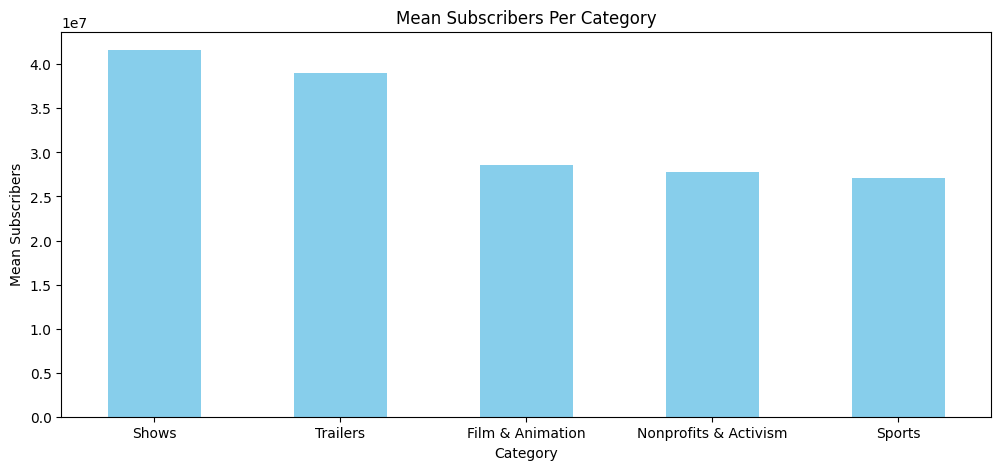

In [14]:
# Create a bar chart for top five categories
category_subscribers_mean.head().plot(kind = "bar", figsize=(12, 5), color="skyblue")
plt.title("Mean Subscribers Per Category")
plt.xlabel("Category")
plt.ylabel("Mean Subscribers")
plt.xticks(rotation = 0)
plt.show()

In [15]:
# To see a particular record, in this case, the first one
df.loc[0]

rank                                                       1
Youtuber                                            T-Series
subscribers                                        245000000
video views                               228,000,000,000.00
category                                               Music
Title                                               T-Series
uploads                                                20082
Country                                                India
Abbreviation                                              IN
channel_type                                           Music
video_views_rank                                        1.00
country_rank                                            1.00
channel_type_rank                                       1.00
video_views_for_the_last_30_days            2,258,000,000.00
lowest_monthly_earnings                           564,600.00
highest_monthly_earnings                        9,000,000.00
lowest_yearly_earnings  

In [16]:
# Get the number of channels in each channel type
channel_type_counts = df["channel_type"].value_counts()
channel_type_counts

channel_type
Entertainment    304
Music            216
People           101
Games             98
Comedy            51
Education         49
Film              42
Howto             36
News              30
Tech              17
Sports            13
Autos              3
Animals            3
Nonprofit          2
Name: count, dtype: int64

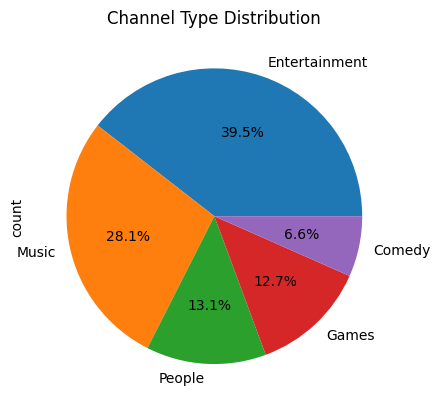

In [17]:
# Create a pie chart sowing the percentage of the top 5 channel types
channel_type_counts.head().plot(kind = "pie",autopct="%1.1f%%")
plt.title("Channel Type Distribution")
plt.show()

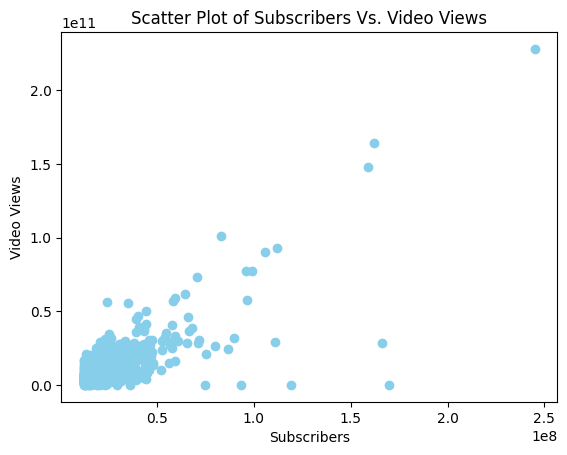

In [18]:
#A scatter plot to see the relationship between two numerical variables Subscribers and Video views
plt.scatter(df["subscribers"],df["video views"], c= "skyblue")
plt.title("Scatter Plot of Subscribers Vs. Video Views")
plt.xlabel("Subscribers")
plt.ylabel("Video Views")
plt.show()

In [19]:
# Get the total subscribers per country
country_subscribers_total= df.groupby("Country")["subscribers"].sum().sort_values(ascending = True)
country_subscribers_total


Country
Samoa                     13100000
Finland                   13200000
Bangladesh                13900000
Peru                      14400000
Morocco                   14500000
Andorra                   15100000
China                     17600000
Malaysia                  17700000
Switzerland               19400000
Latvia                    20200000
Afghanistan               20400000
Ecuador                   27700000
Iraq                      30200000
Kuwait                    30500000
Egypt                     30600000
Venezuela                 31200000
Italy                     39400000
Barbados                  41900000
El Salvador               46100000
Cuba                      46300000
Vietnam                   47800000
Netherlands               58100000
Singapore                 59700000
Sweden                    63000000
Jordan                    67000000
France                    83900000
Chile                     87200000
Turkey                    91600000
Germany     

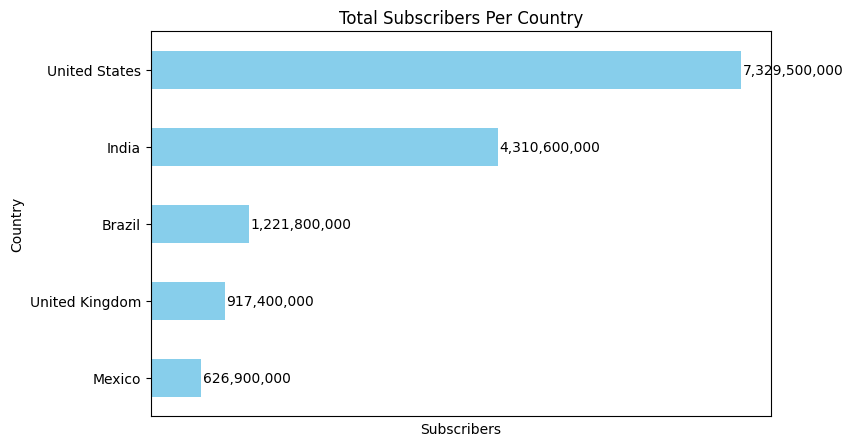

In [20]:
# Create bar chart showing total subscribers per country
ax = country_subscribers_total.tail().plot(kind="barh", color="skyblue", figsize=(8, 5))
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=1, fontsize=10)

plt.title("Total Subscribers Per Country")
plt.xlabel("Subscribers")
plt.ylabel("Country")
plt.xticks([])
plt.show()

In [21]:
# Total Sunscribers by created year
df.groupby("created_year")["subscribers"].mean().sort_values(ascending = True )

created_year
2,022.00   13,640,000.00
2,021.00   18,573,913.04
2,019.00   18,639,393.94
2,017.00   18,666,176.47
2,014.00   20,618,367.35
2,010.00   20,670,833.33
2,015.00   21,247,945.21
2,020.00   21,350,000.00
2,011.00   21,800,000.00
2,018.00   23,060,869.57
2,016.00   23,101,298.70
2,009.00   23,105,769.23
2,008.00   23,652,173.91
2,012.00   24,038,235.29
2,013.00   24,527,631.58
2,007.00   24,902,040.82
2,005.00   25,829,166.67
2,006.00   31,884,615.38
1,970.00   36,300,000.00
Name: subscribers, dtype: float64

In [22]:
# Total Sunscribers by created year
df.groupby("channel_type")["video_views_rank"].median().sort_values(ascending=False)

channel_type
Autos           3,468,229.00
Tech                2,420.00
Games               1,944.00
People              1,868.00
Howto               1,574.50
Nonprofit           1,537.50
Sports              1,186.00
Comedy              1,033.00
Film                  880.00
Entertainment         796.00
News                  611.50
Education             538.00
Music                 385.00
Animals               136.00
Name: video_views_rank, dtype: float64

In [23]:
# To find the country whose channel that achieved maximum subscribers over the last 30 days
df.groupby("Country")["subscribers_for_last_30_days"].max().sort_values(ascending=False)

Country
United States          8,000,000.00
Indonesia              5,500,000.00
United Arab Emirates   3,400,000.00
South Korea            3,200,000.00
Sweden                 3,000,000.00
Turkey                 2,100,000.00
Italy                  2,000,000.00
India                  2,000,000.00
Argentina              1,900,000.00
Colombia               1,600,000.00
Russia                 1,600,000.00
Pakistan               1,300,000.00
Kuwait                 1,300,000.00
Latvia                 1,200,000.00
Brazil                 1,100,000.00
Japan                  1,100,000.00
Germany                  900,000.00
Spain                    800,000.00
Australia                600,000.00
United Kingdom           600,000.00
Mexico                   600,000.00
Philippines              500,000.00
Saudi Arabia             500,000.00
Chile                    500,000.00
Canada                   400,000.00
Ecuador                  300,000.00
Thailand                 300,000.00
Jordan              

In [24]:
# To find the total subscribers over time based on what month the channel waas created
df.groupby("created_month")["subscribers"].sum()

created_month
Apr    1581200000
Aug    1813600000
Dec    1577300000
Feb    1533800000
Jan    2254600000
Jul    1922300000
Jun    1846400000
Mar    2320500000
May    1997700000
Nov    1930200000
Oct    1503700000
Sep    2496200000
Name: subscribers, dtype: int64

In [25]:
# Other calculations
df.groupby("category")["video views"].std()
df.groupby("Country")["Unemployment rate"].min().sort_values(ascending=True)
df.groupby("channel_type")["uploads"].sum()
df.groupby(["Latitude", "Longitude"]).size().sort_values(ascending=False)

Latitude  Longitude
37.09     -95.71       313
20.59     78.96        168
-14.24    -51.93        62
55.38     -3.44         43
23.63     -102.55       33
-0.79     113.92        28
40.46     -3.75         22
15.87     100.99        18
35.91     127.77        17
61.52     105.32        16
56.13     -106.35       15
-38.42    -63.62        13
12.88     121.77        12
4.57      -74.30        11
23.89     45.08          9
-25.27    133.78         9
48.38     31.17          8
23.42     53.85          7
30.38     69.35          6
51.17     10.45          6
36.20     138.25         5
46.23     2.21           5
38.96     35.24          4
60.13     18.64          4
14.06     108.28         3
-35.68    -71.54         3
30.59     36.24          3
52.13     5.29           3
1.35      103.82         3
41.87     12.57          2
-1.83     -78.18         2
26.82     30.80          2
33.22     43.68          2
13.19     -59.54         1
13.79     -88.90         1
6.42      -66.59         1
-9.19   

<function matplotlib.pyplot.show(close=None, block=None)>

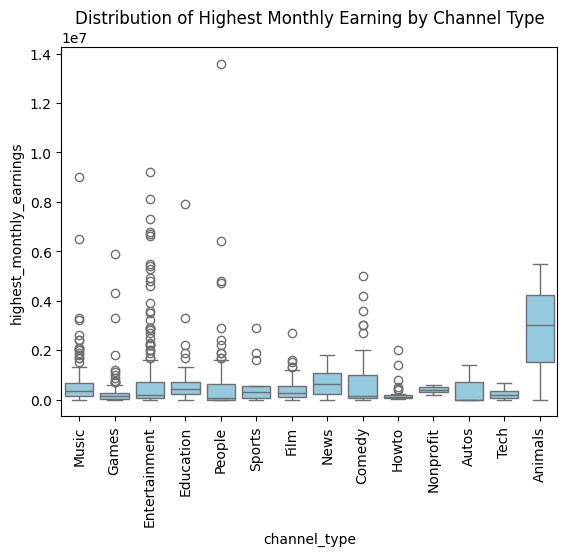

In [26]:
# Create a boxplot to show monthly earning distribution buy channel type
sns.boxplot(x="channel_type", y="highest_monthly_earnings",data=df, color="skyblue")
plt.title("Distribution of Highest Monthly Earning by Channel Type")
plt.xticks(rotation=90)
plt.show

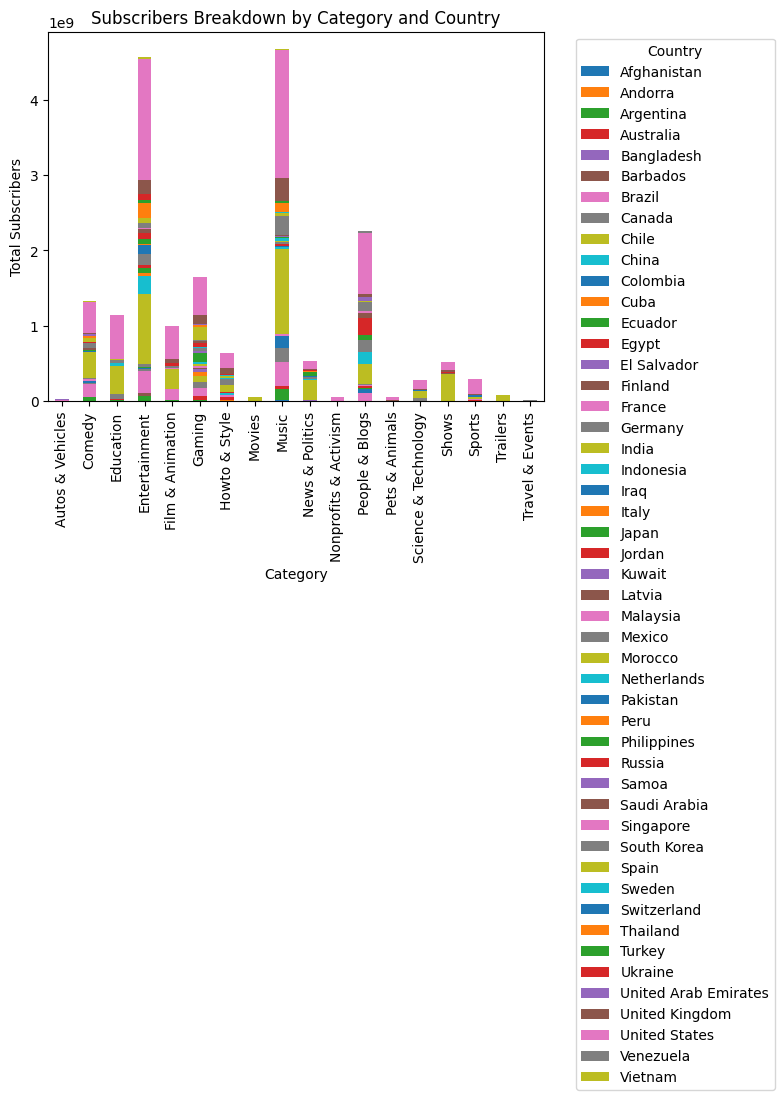

In [42]:
# Create a stacked bar chart that displays subscriber breakdown by category and country
df.groupby(["category","Country"])["subscribers"].sum().unstack().plot(kind="bar",stacked=True)
plt.title("Subscribers Breakdown by Category and Country")
plt.xlabel("Category")
plt.ylabel("Total Subscribers")
plt.legend(title="Country",bbox_to_anchor = (1.05,1),loc="upper left")
plt.xticks(rotation=90)
plt.show()


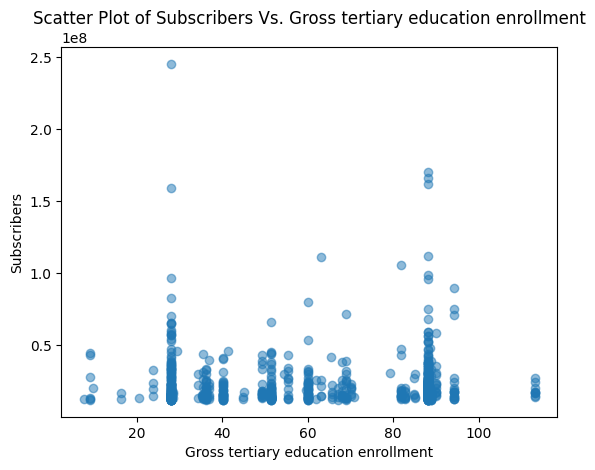

In [28]:
# Create a scatter plot of subscribers vs tertiary education enrollment 
plt.scatter(df["Gross tertiary education enrollment (%)"],df["subscribers"],alpha=0.5)
plt.title("Scatter Plot of Subscribers Vs. Gross tertiary education enrollment")
plt.xlabel("Gross tertiary education enrollment")
plt.ylabel("Subscribers")
plt.show()

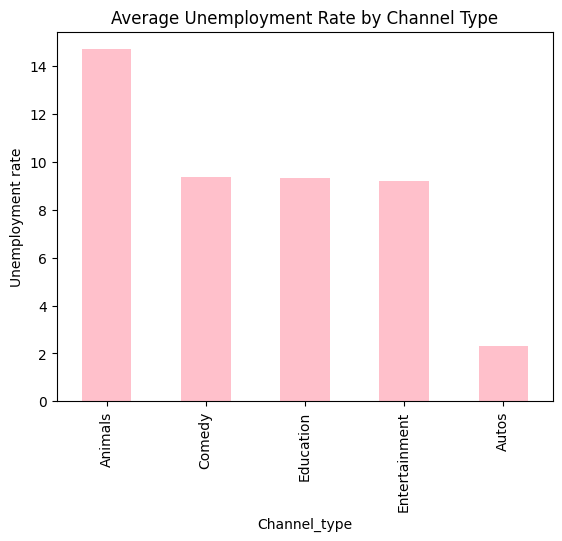

In [29]:
# Create a  bar chart that displays average unemployment rate by channel type
df.groupby("channel_type")["Unemployment rate"].mean().head().sort_values(ascending=False).plot(kind= "bar",color= "pink")
plt.title("Average Unemployment Rate by Channel Type")
plt.xlabel("Channel_type")
plt.ylabel("Unemployment rate")
plt.show()

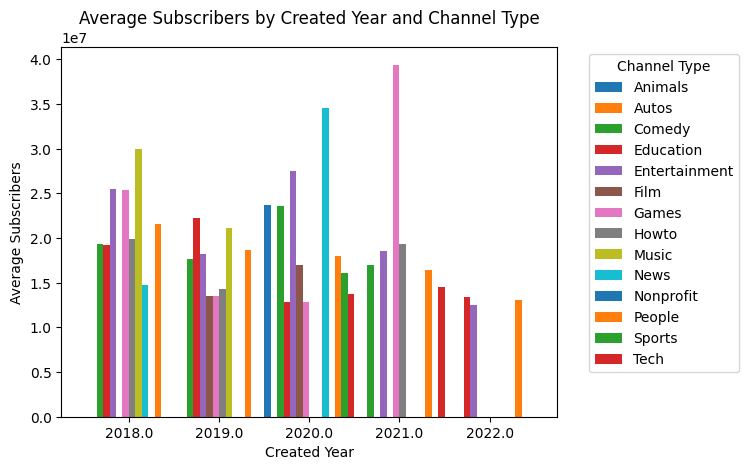

In [48]:
# Create a clustered bar chart that displays average subscriber by created year and channel type
df.groupby(["created_year","channel_type"])["subscribers"].mean().unstack().tail().plot(kind="bar",width=1)
plt.title("Average Subscribers by Created Year and Channel Type")
plt.xlabel("Created Year")
plt.ylabel("Average Subscribers")
plt.legend(title="Channel Type", bbox_to_anchor=(1.05,1),loc="upper left")
plt.xticks(rotation=0)
plt.show()

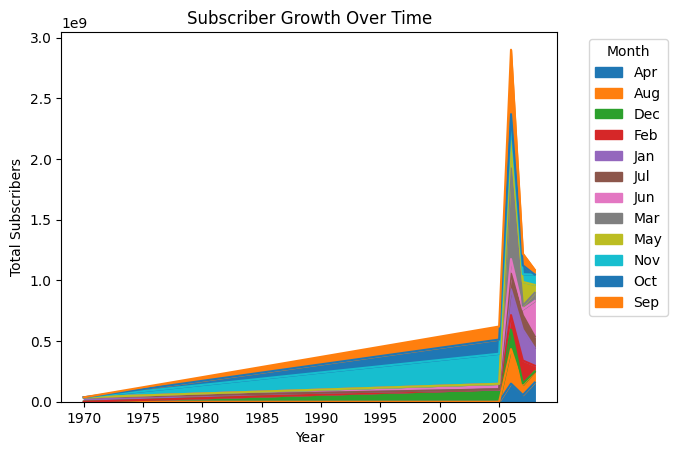

In [31]:
# Create an area chart that displays subscriber breakdown by created year and month
df.groupby(["created_year","created_month"])["subscribers"].sum().unstack().head().plot(kind="area",stacked=True)
plt.title("Subscriber Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Total Subscribers")
plt.legend(title="Month",bbox_to_anchor=(1.05,1),loc="upper left")
plt.show()

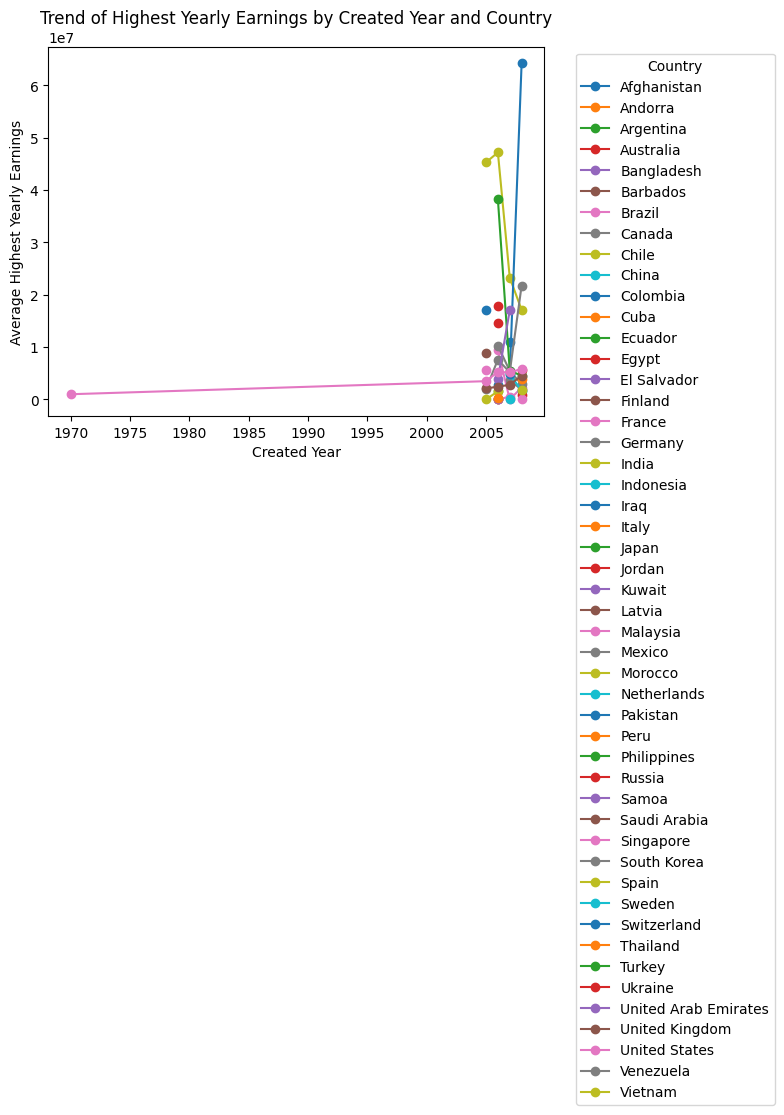

In [32]:
# Create a line chart that displays a trend of average highest yearly earnings per creation year in each country
df.groupby(["created_year","Country"])["highest_yearly_earnings"].mean().unstack().head().plot(kind="line",marker="o")
plt.title("Trend of Highest Yearly Earnings by Created Year and Country")
plt.xlabel("Created Year")
plt.ylabel("Average Highest Yearly Earnings")
plt.legend(title="Country",bbox_to_anchor=(1.05,1),loc="upper left")
plt.show()

In [33]:
# Get the top five categories with the greatest total monthly earnings 
category_highest_monthly_earnings_sum= df.groupby("category")["highest_monthly_earnings"].sum().sort_values(ascending=False).head()
category_highest_monthly_earnings_sum

category
Entertainment      150,056,865.14
Music              111,564,523.95
People & Blogs      72,183,154.16
Comedy              46,113,543.00
Film & Animation    33,704,283.22
Name: highest_monthly_earnings, dtype: float64

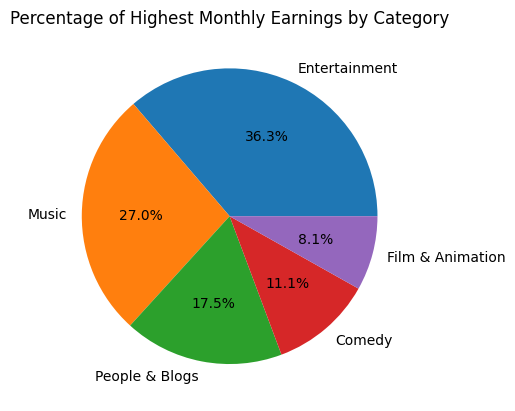

In [34]:
# Create a pie chart that displays the percentages of highest monthly earnings by category 
category_highest_monthly_earnings_sum.plot(kind="pie", autopct="%1.1f%%")
plt.title("Percentage of Highest Monthly Earnings by Category")
plt.ylabel("")
plt.show()

In [35]:
# Get the mean subscribers over the last 30 days for each channel type and split by opening year 
channel_created_subscribers_mean = df.groupby(["channel_type", "created_year"])["subscribers_for_last_30_days"].mean().unstack()
channel_created_subscribers_mean

created_year,"1,970.00","2,005.00","2,006.00","2,007.00","2,008.00","2,009.00","2,010.00","2,011.00","2,012.00","2,013.00","2,014.00","2,015.00","2,016.00","2,017.00","2,018.00","2,019.00","2,020.00","2,021.00","2,022.00"
channel_type,,,,,,,,,,,,,,,,,,,
Animals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"600,000.00",NaN,NaN,NaN,NaN,NaN,"1,100,000.00",NaN,NaN
Autos,NaN,NaN,2.00,"500,000.00",NaN,NaN,NaN,NaN,9.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Comedy,NaN,"400,000.00","100,000.00","100,000.25","200,000.00","400,000.00",NaN,"50,000.50",NaN,"100,000.00","1,166,666.67","150,000.00","700,000.00","100,000.00","200,050.00","1,000,000.00","1,200,000.00","600,000.00",NaN
Education,NaN,NaN,"700,000.00",NaN,"200,000.00","100,000.00","200,000.00","200,000.00","350,000.00","283,333.33","550,000.00","200,000.00","233,333.33","200,000.00","200,000.00","100,000.00","300,000.00",NaN,"300,000.00"
Entertainment,"300,000.00","325,000.00","306,250.50","342,857.29","450,000.00","480,000.00","212,575.00","442,857.14","760,000.00","233,334.00","200,000.00","300,000.00","830,001.40","700,000.00","230,769.23","160,000.00","1,212,500.00","580,000.00","500,000.00"
Film,NaN,1.00,"333,333.33",NaN,"100,000.00",NaN,NaN,"225,007.50","300,000.00","350,000.00","342,857.14","250,000.00","250,000.00","600,000.00",NaN,"500,000.00","450,500.00",NaN,NaN
Games,NaN,"100,000.00",337.67,"50,005.50","100,000.00","200,000.00",3.00,"150,000.00","376,923.15","245,454.55","260,000.00","660,716.00","357,142.86","100,003.33","151,000.00",NaN,"750,000.00",NaN,NaN
Howto,NaN,"500,000.00",NaN,NaN,NaN,"100,000.00","100,000.00",NaN,NaN,NaN,NaN,"100,000.00","100,000.00","100,000.00","633,333.33","100,000.00",NaN,"300,000.00",NaN
Music,NaN,"160,000.20","433,333.67","146,159.62","185,384.85","153,846.15","175,000.00","158,829.41","200,000.00","400,000.00","230,769.23","125,016.25","240,010.00","300,000.00","300,000.00","50,005.00",NaN,NaN,NaN


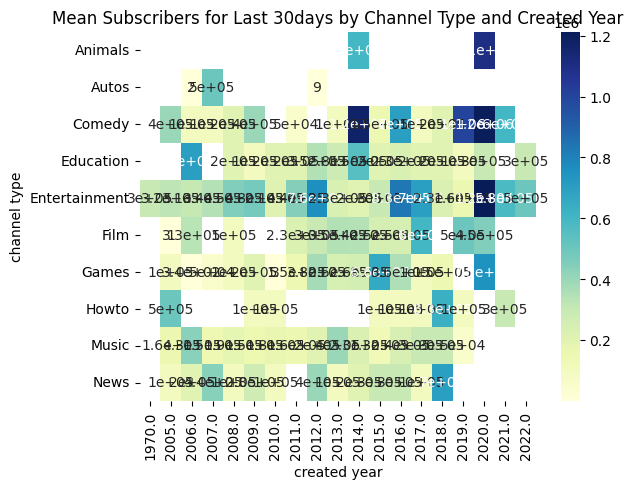

In [36]:
# Create a heatmap for the mean subscribers by channel type and created year
sns.heatmap(channel_created_subscribers_mean.head(10),cmap= "YlGnBu", annot=True)
plt.title("Mean Subscribers for Last 30days by Channel Type and Created Year")
plt.xlabel("created year")
plt.ylabel("channel type")
plt.show()

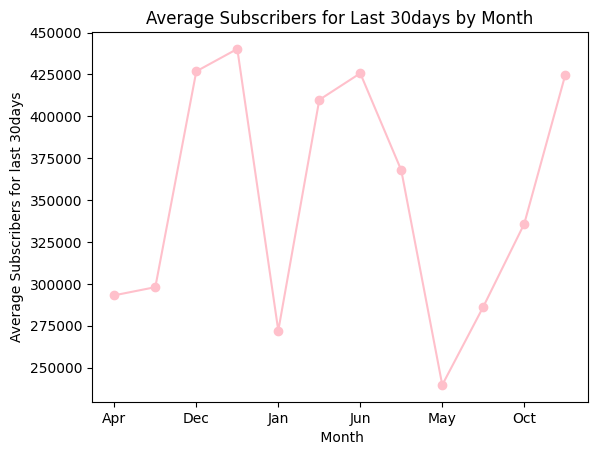

In [37]:
# Create a line chart that displays a trend of average subscriber count by creation month 
df.groupby("created_month")["subscribers_for_last_30_days"].mean().plot(kind="line",marker="o",color="pink")
plt.title("Average Subscribers for Last 30days by Month")
plt.xlabel(" Month")
plt.ylabel("Average Subscribers for last 30days")
plt.show()